In [2]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt

In [3]:
np.random.seed(0) #For reproducibility

In [4]:
#Dogs: higher ear flappiness index, lower whisker length
dogs_whisker_lenth=np.random.normal(loc=5,scale=1, size=10)
dogs_ear_flappiness_index=np.random.normal(loc=8, scale=1, size=10)

In [5]:
#Cats:lower ear flappiness index, higher whisker length
cats_whisheker_length=np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index=np.random.normal(loc=5,scale=1, size=10)

In [6]:
#Combine data
dogs_data=np.vstack((dogs_whisker_lenth, dogs_ear_flappiness_index)).T
cats_data=np.vstack((cats_whisheker_length, cats_ear_flappiness_index)).T
data=np.vstack((dogs_data,cats_data))
labels=np.hstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))


In [7]:
data
labels

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [8]:
#Split data into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(data, labels,test_size=0.2,random_state=42)

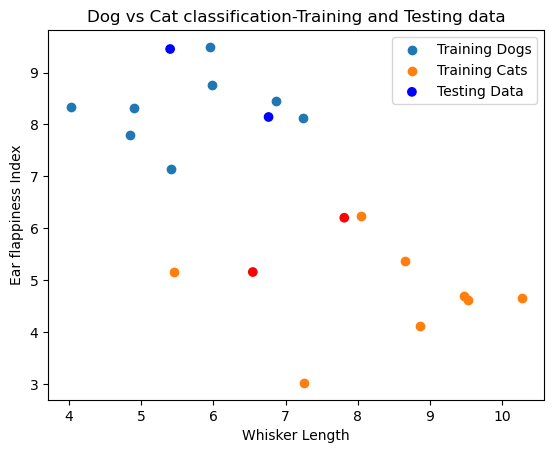

In [9]:
#plotting the training and testing data points
plt.scatter(X_train[y_train==0][:,0],X_train[y_train==0][:,1],label="Training Dogs")
plt.scatter(X_train[y_train==1][:,0],X_train[y_train==1][:,1],label="Training Cats")
plt.scatter(X_test[:,0],X_test[:,1],c=y_test, cmap='bwr', label="Testing Data")
plt.xlabel("Whisker Length")
plt.ylabel("Ear flappiness Index")
plt.title("Ear flappiness Index")
plt.title("Dog vs Cat classification-Training and Testing data")
plt.legend()
plt.show()


In [10]:
#Implementing the random linear classifier ALgorithm

def random_linear_classifier(data_dogs, data_cats,k,d):
    #d is the number of features
    best_error=float('inf')
    best_theta=None
    best_theta0=None

    for _ in range(k):
        theta=np.random.normal(size=d)
        theta0=np.random.normal()

        error=compute_error(data_dogs,data_cats,theta,theta0)

        if error<best_error:
            best_error=error
            best_theta=theta
            best_theta0=theta0

    return best_theta, best_theta0, best_error


In [11]:
def compute_error(data_dogs, data_cats, theta, theta0):
    error=0
    for x_dog in data_dogs:
        if np.dot(theta, x_dog)+theta0<=0:
            error+=1
    for x_cat in data_cats:
        if np.dot(theta, x_cat)+theta0>0:
            error+=1
    return error

In [35]:
#Define function for k-fold cross-validation
def cross_validate(data_dogs, data_cats, k_values,d,n_splits=5):
    kf=KFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_errors=[]

    for k in k_values:
        errors=[]

        for train_index, val_index in kf.split(data_dogs):
            X_train_fold=np.vstack((data_dogs[train_index], data_cats[train_index]))
            y_train_fold=np.hstack((np.zeros(len(train_index)), np.ones(len(train_index))))
            X_val_fold=np.vstack((data_dogs[val_index], data_cats[val_index]))
            y_val_fold=np.hstack((np.zeros(len(val_index)),np.ones(len(val_index))))

            best_theta_fold, best_theta0_fold, error=random_linear_classifier(X_train_fold[y_train_fold==0],
                                                                             X_train_fold[y_train_fold==1],k,d)
            errors.append(compute_error(X_val_fold[y_val_fold==0], X_val_fold[y_val_fold==1],
                                        best_theta_fold, best_theta0_fold))

        avg_errors.append(np.mean(errors))

    best_k=k_values[np.argmin(avg_errors)]
    return best_k

#Define k values to try
k_values=[1,10,50,100,200]
best_k=cross_validate(dogs_data,cats_data, k_values, d=2)
print(f"Best value of k={best_k}")

 



Best value of k=100


In [36]:
#Run random linear classifier algorithm
k=100 #number of iterations
d=2 #Number of features 
best_theta_train, best_theta0_train, train_error=random_linear_classifier(X_train[y_train==0],X_train[y_train==1],k,d)

In [13]:
#PLot the decision boundary on training data
x_vals_train=np.linspace(2,10,100)
y_vals_train=(-best_theta_train[0]/best_theta_train[1])*x_vals_train-(best_theta0_train/best_theta_train[1])

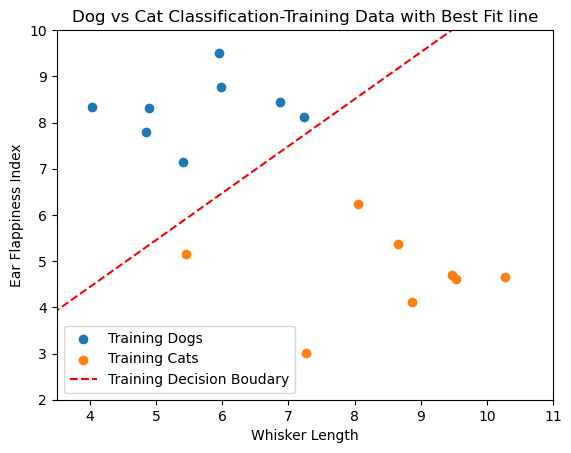

In [16]:
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], label='Training Dogs')
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], label='Training Cats')
plt.plot(x_vals_train,y_vals_train,color='red',linestyle='--',label="Training Decision Boudary")
#Set same limits for x and y axes
plt.xlim([3.5,11])
plt.ylim([2,10])
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title("Dog vs Cat Classification-Training Data with Best Fit line")
plt.legend()
plt.show()


In [17]:
print(f'Trainig Error:{train_error}')

Trainig Error:0


In [18]:
#Compute Testing error
test_error=compute_error(X_test[y_test==0],X_test[y_test==1], best_theta_train, best_theta0_train)
print(f"Testing Error:{test_error}")

Testing Error:0


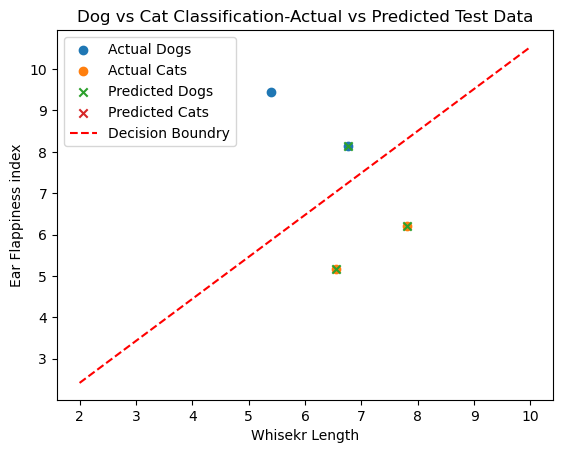

In [ ]:
#plot the actual test data and predicted test data
plt.scatter(X_test[y_test==0][:,0],X_test[y_test==0][:, 1], label='Actual Dogs')
plt.scatter(X_test[y_test==1][:,0],X_test[y_test==1][:, 1], label='Actual Cats')
#Predict test data points using decision boundary
predicted_labels=np.zeros_like(y_test)
for i, x_test in enumerate(X_test):
    if np.dot(best_theta_train,x_test)+best_theta0_train>0:
        predicted_labels[i]=i
    
#Plot predicted test data points 
plt.scatter(X_test[predicted_labels==0][:,0],X_test[predicted_labels==0][:,1],marker='x',label='Predicted Dogs')
plt.scatter(X_test[predicted_labels==1][:,0],X_test[predicted_labels==1][:,1],marker='x',label='Predicted Cats')

#Plot decision boundary
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label='Decision Boundry')
plt.xlabel("Whisker Length")
plt.ylabel("Ear Flappiness index")
plt.title("Dog vs Cat Classification-Actual vs Predicted Test Data")
plt.legend()
plt.show()
